# Time-to-event prediction with C-MAPSS

This example downloads C-MAPSS, constructs cycles-to-failure with Polars, and trains a simple regression baseline.

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "datasets").is_dir():
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

import datasets

In [3]:
datasets.summary(downloadable=True)
downloaded = datasets.download("cmapss")
print("Archive:", downloaded["archive"])
print("SHA-256:", downloaded["sha256"])

ID      Short name  Dataset                                                 Availability  Download  License      Tasks
------  ----------  ------------------------------------------------------  ------------  --------  -----------  ------------------------------------------------------
cbm     CBM         Condition Based Maintenance of Naval Propulsion Plants  available     yes       CC BY 4.0    Condition estimation, Regression
cmapss  C-MAPSS     Turbofan Engine Degradation Simulation Data Set         available     yes       Unspecified  RUL estimation, Prognostics, Anomaly detection
gfd     GFD         Gearbox Fault Diagnosis Data                            available     yes       CC BY 4.0    Fault classification, Signal analysis
hydsys  HydSys      Condition Monitoring of Hydraulic Systems               available     yes       CC BY 4.0    Fault classification, Condition estimation, Regression
ufd     UFD         Ultrasonic Flowmeter Diagnostics                        available   

In [4]:
data = datasets.load("cmapss", subset="FD001", split="train")
data.head()

unit_number,cycle,operation_1,operation_2,operation_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
u16,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64
1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
1,4,0.0007,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


## Construct the event-time target

The last observed cycle of each training engine is its failure cycle.

In [5]:
data = data.with_columns(
    (pl.col("cycle").max().over("unit_number") - pl.col("cycle"))
    .alias("time_to_event_cycles"),
    pl.lit(True).alias("event_observed"),
)
data.select("unit_number", "cycle", "time_to_event_cycles", "event_observed").head()

unit_number,cycle,time_to_event_cycles,event_observed
u16,u32,u32,bool
1,1,191,true
1,2,190,true
1,3,189,true
1,4,188,true
1,5,187,true


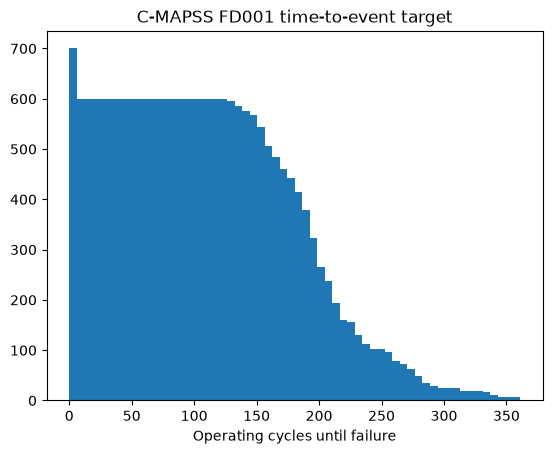

In [6]:
plt.hist(data.get_column("time_to_event_cycles").to_numpy(), bins=60)
plt.xlabel("Operating cycles until failure")
plt.title("C-MAPSS FD001 time-to-event target")
plt.show()

## Split by engine and train a baseline

Engine identifiers, rather than individual rows, define the holdout split.

In [7]:
unit_numbers = data.get_column("unit_number").unique().sort().to_numpy()
split_index = int(len(unit_numbers) * 0.8)
training_units = unit_numbers[:split_index]
test_units = unit_numbers[split_index:]

train = data.filter(pl.col("unit_number").is_in(training_units))
test = data.filter(pl.col("unit_number").is_in(test_units))
print(f"Training engines: {len(training_units)}")
print(f"Test engines: {len(test_units)}")

Training engines: 80
Test engines: 20


In [8]:
features = [
    column for column in data.columns
    if column.startswith(("operation_", "sensor_"))
]
model = HistGradientBoostingRegressor(loss="absolute_error", random_state=0)
model.fit(train.select(features).to_numpy(), train.get_column("time_to_event_cycles").to_numpy())
prediction = model.predict(test.select(features).to_numpy())

mae_cycles = mean_absolute_error(
    test.get_column("time_to_event_cycles").to_numpy(), prediction
)
print(f"Test MAE: {mae_cycles:.1f} cycles")

Test MAE: 37.5 cycles


In [9]:
comparison = test.select(
    "unit_number",
    "cycle",
    pl.col("time_to_event_cycles").alias("actual_cycles"),
).with_columns(pl.Series("predicted_cycles", prediction))
comparison.sample(n=min(10, comparison.height), seed=0)

unit_number,cycle,actual_cycles,predicted_cycles
u16,u32,u32,f64
86,254,24,20.273672
88,57,156,119.264394
87,134,44,53.322437
81,52,188,133.770135
90,135,19,43.53461
81,93,147,126.885818
97,100,102,143.832584
97,48,154,151.196133
86,123,155,118.943488
